# Battery Data Analysis
This notebook shows my step by step work on battery data.

## Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load Data

Load the dataset and mapping file required for analysis.


In [ ]:
#read data
Battery_DataFrame = pd.read_csv("../data/battery_data_logs.csv")
code = pd.read_csv("../data/data_code_details.csv")

## COLUMN RENAMING USING MAPPING FILE

Convert encoded column names into readable format.

Processing Steps:
1. Load mapping file containing code-to-name relationships
2. Create mapping dictionary from code and name columns
3. Rename dataset columns using the mapping dictionary

Reason:
Raw dataset contains encoded column names which are difficult to interpret.

Purpose:
Improve readability and make the dataset easier to understand for analysis.


In [ ]:
#map
map = dict(zip(code['code'],code['name']))

#rename columns
Battery_DataFrame.rename(columns=map, inplace=True)

## Time Processing

Convert timestamp into datetime format and prepare time-based data.

Processing Steps:
1. Convert timestamp column into datetime format
2. Sort the dataset based on timestamp
3. Create a new date column from timestamp

Reason:
Time-based operations require proper datetime format.

Purpose:
Ensures correct ordering and enables daily analysis.

In [ ]:
#new column timestamp
Battery_DataFrame['timestamp'] = pd.to_datetime(Battery_DataFrame['generated_at'])

#sort based on timestamp
Battery_DataFrame = Battery_DataFrame.sort_values('timestamp')

#new column date
Battery_DataFrame['date'] = Battery_DataFrame['timestamp'].dt.date

## Data Availability Analysis

Evaluate how much data is available for each day.

Processing Steps:
1. Group data by date and count total records per day
2. Compare actual count with expected value (96 records per day)
3. Categorize each day:
   - Perfect  : count = 96
   - Missing  : count < 96
   - Extra    : count > 96
4. Calculate availability percentage:
   (Actual Count / 96) * 100
5. Compute average availability

Reason:
Data is expected every 15 minutes, so missing or extra records indicate data quality issues.

Purpose:
Assess completeness of the dataset and identify days with poor data quality.

In [ ]:
daily_count = Battery_DataFrame.groupby(Battery_DataFrame['date']).size().reset_index(name='count')

def check_count(a):
    if a > 96:
        return 'Extra'
    elif a < 96:
        return 'Missing'
    else:
        return 'Perfect'

daily_count['state'] = daily_count['count'].apply(check_count)

availability = (daily_count['count']/96)*100
daily_count['availability'] = availability
avg_availability = daily_count['availability'].mean()
print(daily_count.head())
print("\n")
print(f'Average Availability : {avg_availability:.4f}')


         date  count    state  availability
0  2025-08-03     68  Missing     70.833333
1  2025-08-04    119    Extra    123.958333
2  2025-08-05    144    Extra    150.000000
3  2025-08-06    131    Extra    136.458333
4  2025-08-07    144    Extra    150.000000


Average Availability : 135.4562


## CHARGING, DISCHARGING AND CYCLE DETECTION

Identify battery operating states and detect charge/discharge cycles.

Processing Steps:
1. Classify battery state using current values:
   - Charging    : current > 100
   - Discharging : current < -100
   - Idle        : otherwise
2. Remove idle data to focus on active battery behavior
3. Detect state changes between consecutive records
4. Mark state change points as cycle boundaries
5. Assign unique cycle IDs using cumulative sum
6. Count total number of cycles

Reason:
Cycle detection requires identifying transitions between charging and discharging states.

Purpose:
Understand battery usage pattern and how frequently it is charged and discharged.



In [ ]:
Battery_DataFrame['state'] = np.where(Battery_DataFrame['Battery current'] > 100, 'charging' , np.where(Battery_DataFrame['Battery current'] < -100, 'discharging','idle'))

Battery_DataFrame['state_charge'] = Battery_DataFrame['state'] != Battery_DataFrame['state'].shift()

Battery_DataFrame_filtered= Battery_DataFrame[Battery_DataFrame['state'] != 'idle'].copy()

Battery_DataFrame_filtered['state_charge'] = Battery_DataFrame_filtered['state'] != Battery_DataFrame_filtered['state'].shift()
Battery_DataFrame_filtered['cycle'] = Battery_DataFrame_filtered['state_charge'].cumsum()

total_cycle = Battery_DataFrame_filtered['cycle'].nunique()
print("Total Cycle: ", total_cycle)

Total Cycle:  480


## TIME DIFFERENCE CALCULATION AND FILTERING

Calculate time gaps between consecutive records and remove abnormal intervals.

Processing Steps:
1. Compute time difference between consecutive timestamps
2. Convert time difference into minutes
3. Apply threshold filtering:
   - Keep records where time_diff ≤ 30 minutes
   - Remove records where time_diff > 30 minutes

Reason:
Data is expected at 15-minute intervals. Small gaps are acceptable, 
but large gaps indicate missing or inconsistent data.

Purpose:
Ensure continuity in time-series data and improve reliability of analysis.


In [ ]:
Battery_DataFrame['time_diff'] = Battery_DataFrame['timestamp'].diff().dt.total_seconds()/60
Battery_DataFrame_filtered['time_diff'] = Battery_DataFrame_filtered['timestamp'].diff().dt.total_seconds()/60

Battery_DataFrame_filtered = Battery_DataFrame_filtered[Battery_DataFrame_filtered['time_diff'] <= 30]

## CYCLE DURATION ANALYSIS

Calculate the duration of charging and discharging cycles.

Processing Steps:
1. Use filtered data with valid time intervals
2. Group data by cycle and state (charging or discharging)
3. Sum time_diff values to get total duration for each cycle
4. Compute average duration for:
   - Charging cycles
   - Discharging cycles
5. Identify cycles with unusually high duration

Reason:
Accurate duration calculation requires continuous and valid time intervals. 
Filtering ensures that abnormal gaps do not distort the results.

Purpose:
Analyze how long the battery takes to charge and discharge, 
and identify irregular cycle behavior.

In [ ]:
cycle_time = Battery_DataFrame_filtered.groupby(['cycle','state'])[['time_diff']].sum().reset_index()

charging_time = cycle_time[cycle_time['state'] == 'charging']
discharging_time = cycle_time[cycle_time['state'] == 'discharging']

avg_charging_time = charging_time['time_diff'].mean()
avg_discharging_time = discharging_time['time_diff'].mean()

print(f"Average Charging Time: {avg_charging_time:.4f}")
print(f"Average Discharging Time: {avg_discharging_time:.4f}")

Average Charging Time: 379.6744
Average Discharging Time: 182.6393


## ANOMALY DETECTION (CYCLE DURATION)
Identify abnormal cycles based on duration.

Processing Steps:
1. Use calculated cycle duration data
2. Compute average duration for charging and discharging cycles
3. Define anomaly threshold:
   - Cycle duration > 2 × average duration
4. Flag cycles that exceed the threshold as anomalies

Reason:
Significantly higher cycle duration often indicates missing data, 
large time gaps, or irregular battery behavior.

Purpose:
Detect unusual patterns in battery operation and highlight cycles 
that require further investigation.

In [11]:
charging_anomaly = charging_time[charging_time['time_diff'] > (2 * avg_charging_time)]
print("Charging Anomalies:")
print(charging_anomaly.head())
print("\n")
discharging_anomaly = discharging_time[discharging_time['time_diff'] > (2 * avg_discharging_time)]
print("Discharging Anomalies:")
print(discharging_anomaly.head())

Charging Anomalies:
     cycle     state    time_diff
262    269  charging   767.583333
314    321  charging  1218.083333
337    345  charging   761.750000
346    355  charging   776.166667
388    397  charging   796.666667


Discharging Anomalies:
     cycle        state  time_diff
14      16  discharging     387.75
209    216  discharging     375.00
243    250  discharging     405.00
355    364  discharging     396.15
367    376  discharging     420.00


## ENERGY CALCULATION AND EFFICIENCY ANALYSIS

Calculate energy flow into and out of the battery and evaluate efficiency.

Processing Steps:
1. Use cumulative Ah_in and Ah_out values
2. Compute difference between consecutive records to get actual energy change:
   - Ah_in_diff  : energy input at each step
   - Ah_out_diff : energy output at each step
3. Calculate total energy:
   - Charging energy    : sum of Ah_in_diff
   - Discharging energy : sum of Ah_out_diff
4. Compute efficiency:
   Efficiency = Total Output Energy / Total Input Energy

Reason:
Ah_in and Ah_out are cumulative values. Taking the difference between 
consecutive records is necessary to obtain actual step-wise energy flow.

Purpose:
Evaluate battery performance by measuring how efficiently input energy 
is converted into usable output energy.

In [ ]:
Battery_DataFrame['Ah_in_diff'] = Battery_DataFrame['Ah_in_sum over lifetime'].diff()
Battery_DataFrame['Ah_out_diff'] = Battery_DataFrame['Ah_out_sum over lifetime'].diff()

charging_enargy = Battery_DataFrame[Battery_DataFrame['state'] == 'charging']['Ah_in_diff'].sum()
discharging_enargy = Battery_DataFrame[Battery_DataFrame['state'] == 'discharging']['Ah_out_diff'].sum()

print("Charging Energy:", charging_enargy)
print("Discharging Energy:", discharging_enargy)

efficiency =  discharging_enargy / charging_enargy
print(f"Efficiency: {efficiency:.4f}%")

Charging Energy: 17749846.0
Discharging Energy: 11984977.0
Efficiency: 0.6752%



## AVERAGE ENERGY ANALYSIS

Calculate average energy input and output per step.

Processing Steps:
1. Use Ah_in_diff and Ah_out_diff values
2. Compute average values:
   - Average Ah_in  : mean of Ah_in_diff
   - Average Ah_out : mean of Ah_out_diff

Reason:
Step-wise energy differences represent actual energy flow. 
Averaging these values provides a typical energy profile.

Purpose:
Understand typical energy input and output behavior 
and analyze overall battery usage patterns.


In [ ]:
avg_ah_in = Battery_DataFrame[Battery_DataFrame['state']=='charging']['Ah_in_diff'].mean()
avg_ah_out = Battery_DataFrame[Battery_DataFrame['state']=='discharging']['Ah_out_diff'].mean()

print(f"Average Ah_in: {avg_ah_in:.4f}")
print(f"Average Ah_out: {avg_ah_out:.4f}")

Average Ah_in: 2229.8802
Average Ah_out: 4073.7515


## IDLE TIME ANALYSIS

Measure how much time the battery remains idle.

Processing Steps:
1. Filter rows where battery state is idle
2. Remove records with large time gaps (time_diff > 30 minutes)
3. Calculate total idle time by summing time_diff
4. Calculate total valid time from the dataset
5. Compute idle percentage:
   Idle (%) = (Idle Time / Total Time) × 100

Reason:
Data is expected at 15-minute intervals. A threshold of 30 minutes 
is used to allow small gaps while removing large missing intervals 
that can distort idle time calculation.

Purpose:
Evaluate how much time the battery remains unused and assess 
overall usage efficiency.

In [ ]:
idle_data= Battery_DataFrame[Battery_DataFrame['state'] == 'idle'] 
idle_data = idle_data[idle_data['time_diff'] <=30]
total_idle_time= idle_data['time_diff'].sum()

total_time = Battery_DataFrame[Battery_DataFrame['time_diff'] <= 30]['time_diff'].sum()
idle_percentage = (total_idle_time / total_time)*100

print(f"Idle Percentage: {idle_percentage:.4f}%")

Idle Percentage: 58.4706%


## DAY-WISE EFFICIENCY ANALYSIS
Evaluate battery efficiency on a daily basis.

Processing Steps:
1. Group data by date
2. Calculate total daily energy:
   - Total Ah_in  : sum of Ah_in_diff
   - Total Ah_out : sum of Ah_out_diff
3. Compute daily efficiency:
   Efficiency = Total Ah_out / Total Ah_in

Reason:
Overall efficiency may hide daily variations. 
Calculating efficiency per day helps reveal performance changes over time.

Purpose:
Analyze battery performance trends and identify variations in efficiency 
across different days.

In [ ]:
daily_energy = Battery_DataFrame.groupby('date')[['Ah_in_diff', 'Ah_out_diff']].sum().reset_index()

daily_energy['efficiency'] = daily_energy['Ah_out_diff'] / daily_energy['Ah_in_diff']
print(daily_energy.head())

         date  Ah_in_diff  Ah_out_diff  efficiency
0  2025-08-03     96552.0          0.0    0.000000
1  2025-08-04    122379.0     120781.0    0.986942
2  2025-08-05     92913.0      90427.0    0.973244
3  2025-08-06    127323.0     125385.0    0.984779
4  2025-08-07    105307.0     100756.0    0.956783


## PEAK CHARGING DAYS ANALYSIS

Identify days with highest charging activity.

Processing Steps:
1. Filter data for charging state only
2. Group data by date
3. Calculate total charging energy per day:
   - Sum of Ah_in_diff
4. Sort daily values in descending order
5. Select top days with highest charging energy

Reason:
Analyzing total charging energy per day helps identify periods 
of high battery usage.

Purpose:
Highlight peak usage days and understand charging behavior patterns.

In [ ]:
daily_charge = Battery_DataFrame[Battery_DataFrame['state']=='charging'].groupby('date')['Ah_in_diff'].sum().reset_index()

daily_charge.columns = ['Date', 'Total Charging (Ah)']

top_days = daily_charge.sort_values('Total Charging (Ah)', ascending=False).head()
print(top_days)

           Date  Total Charging (Ah)
14   2025-08-30            1676709.0
8    2025-08-12             344527.0
175  2026-04-01             151309.0
19   2025-09-04             147503.0
16   2025-09-01             145878.0


## BATTERY USAGE PATTERN CLASSIFICATION
Classify daily battery usage based on data quality and performance.

Processing Steps:
1. Combine daily availability and efficiency into a single dataset
2. Define classification rules:
   - Low Data   : availability < 80
   - Good Usage : efficiency > 0.7
   - Normal     : otherwise
3. Apply rules to assign a usage category for each day

Reason:
Combining data availability and efficiency provides a more complete 
view of battery usage behavior.

Purpose:
Categorize daily usage patterns to easily identify low-quality data days, 
high-performance days, and normal operation periods.

In [ ]:
final = daily_count.merge(daily_energy, on='date')
final.to_excel("../output/final.xlsx",index=False)
print(final.head())

def classify(row):
    if row['availability'] < 80:
        return "Low Data"
    elif row['efficiency'] > 0.7:
        return "Good Usage"
    else:
        return "Normal"
    
final['usage_type'] = final.apply(classify, axis=1)
print("\n")
print(final[['date','availability','efficiency','usage_type']].head())

         date  count    state  availability  Ah_in_diff  Ah_out_diff  \
0  2025-08-03     68  Missing     70.833333     96552.0          0.0   
1  2025-08-04    119    Extra    123.958333    122379.0     120781.0   
2  2025-08-05    144    Extra    150.000000     92913.0      90427.0   
3  2025-08-06    131    Extra    136.458333    127323.0     125385.0   
4  2025-08-07    144    Extra    150.000000    105307.0     100756.0   

   efficiency  
0    0.000000  
1    0.986942  
2    0.973244  
3    0.984779  
4    0.956783  


         date  availability  efficiency  usage_type
0  2025-08-03     70.833333    0.000000    Low Data
1  2025-08-04    123.958333    0.986942  Good Usage
2  2025-08-05    150.000000    0.973244  Good Usage
3  2025-08-06    136.458333    0.984779  Good Usage
4  2025-08-07    150.000000    0.956783  Good Usage


## ABNORMAL DAY DETECTION
Identify days with abnormal data quality or battery performance.

Processing Steps:
1. Use combined dataset with availability and efficiency
2. Apply abnormal conditions:
   - availability < 80
   - efficiency < 0.5
3. Filter days that meet any of these conditions
4. Extract relevant columns (date, availability, efficiency)

Reason:
Low availability indicates incomplete data, while low efficiency 
indicates poor battery performance. Both conditions signal abnormal behavior.

Purpose:
Highlight problematic days for further investigation and improve 
data reliability and performance monitoring.

In [18]:
abnormal_days = final[(final['availability'] < 80) | (final['efficiency'] < 0.5)]

print(abnormal_days[['date','availability','efficiency']])

           date  availability  efficiency
0    2025-08-03     70.833333    0.000000
7    2025-08-10     30.208333   75.503432
13   2025-08-17     73.958333    4.642357
22   2025-09-07     69.791667    1.155494
23   2025-09-08      4.166667    0.000000
33   2025-10-19     35.416667    1.563805
35   2025-10-23     21.875000    0.058287
49   2025-11-19     44.791667    0.000000
52   2025-11-24    110.416667    0.000000
54   2025-11-26    103.125000    0.000000
59   2025-12-01    122.916667    0.000000
95   2026-01-06     11.458333    0.000000
117  2026-01-30     38.541667    0.944783
137  2026-02-19    115.625000    0.008242
139  2026-02-21    135.416667    0.013004
141  2026-02-23    114.583333    0.131494
144  2026-02-26    103.125000    0.000000
152  2026-03-06    111.458333    0.156118
153  2026-03-07    108.333333    0.000000
157  2026-03-11    111.458333    0.000000
159  2026-03-13    134.375000    0.000000
171  2026-03-25    171.875000    0.000000
172  2026-03-26     60.416667    2

## AVAILABILITY GRAPH

Visualize daily data availability percentage.

Processing Steps:
1. Use daily availability data
2. Plot availability percentage against date
3. Add reference line for ideal availability (100%)

Reason:
Visual representation makes it easier to identify missing or inconsistent data.

Purpose:
Understand data completeness across different days.

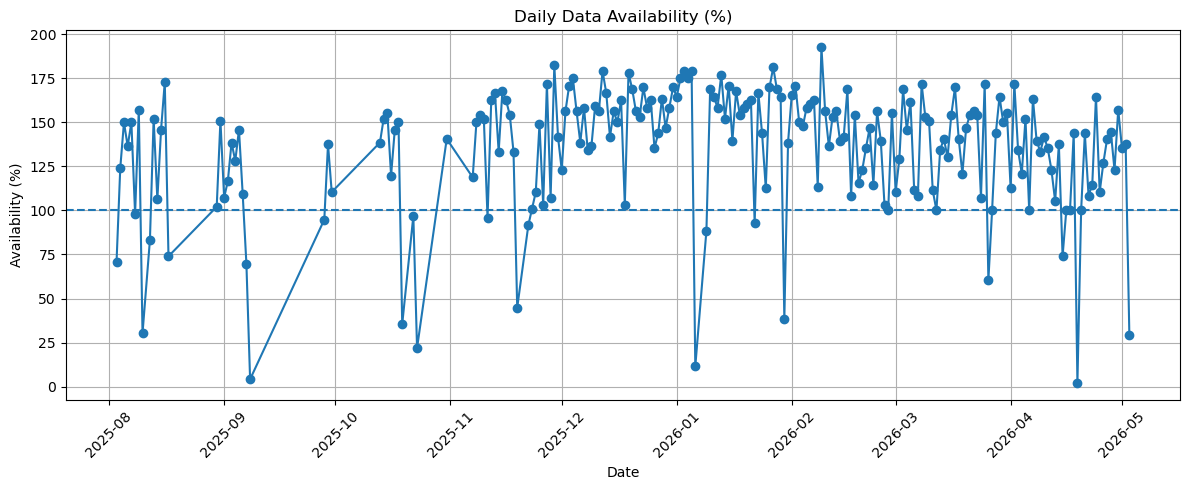

In [19]:

plt.figure(figsize=(12,5))

plt.plot(daily_count['date'], daily_count['availability'], marker='o')

plt.axhline(100, linestyle='--')  # ideal line

plt.title("Daily Data Availability (%)")
plt.xlabel("Date")
plt.ylabel("Availability (%)")

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## CYCLE TREND GRAPH

Visualize daily charging and discharging cycles.

Processing Steps:
1. Group data by date and state (charging/discharging)
2. Count number of cycles per day
3. Plot cycle counts against date for both states

Reason:
Cycle count reflects how frequently the battery is used.

Purpose:
Analyze battery usage pattern and identify high activity periods.

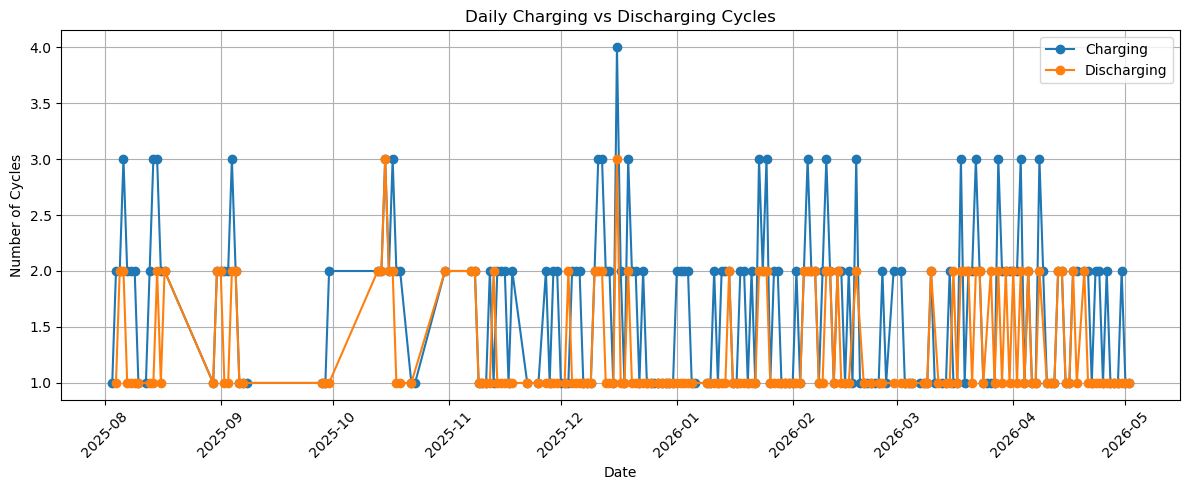

In [ ]:
Battery_DataFrame_filtered['date'] = Battery_DataFrame_filtered['timestamp'].dt.date

daily_cycles = Battery_DataFrame_filtered.groupby(['date','state'])['cycle'].nunique().reset_index()

plt.figure(figsize=(12,5))

charging = daily_cycles[daily_cycles['state'] == 'charging']
plt.plot(charging['date'], charging['cycle'], label='Charging', marker='o')

discharging = daily_cycles[daily_cycles['state'] == 'discharging']
plt.plot(discharging['date'], discharging['cycle'], label='Discharging', marker='o')

plt.legend()
plt.title("Daily Charging vs Discharging Cycles")
plt.xlabel("Date")
plt.ylabel("Number of Cycles")

plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## DURATION DISTRIBUTION GRAPH

Visualize distribution of charging and discharging durations.

Processing Steps:
1. Use calculated cycle duration data
2. Plot histogram for charging durations
3. Plot histogram for discharging durations

Reason:
Distribution helps identify common durations and outliers.

Purpose:
Understand typical cycle duration and variation in battery behavior.


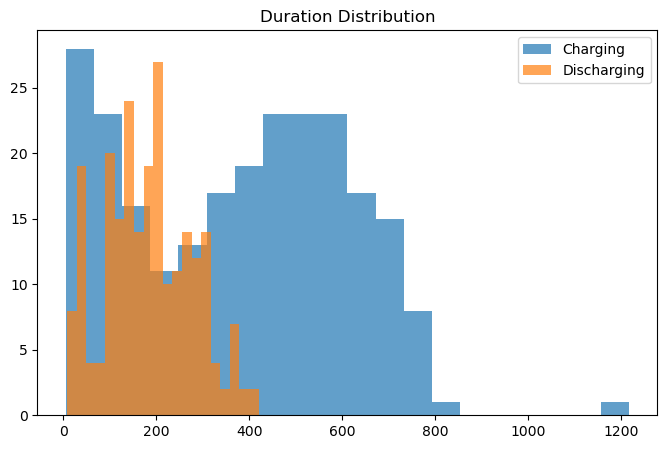

In [21]:
# ===== Duration Distribution =====
plt.figure(figsize=(8,5))

plt.hist(charging_time['time_diff'], bins=20, alpha=0.7, label='Charging')
plt.hist(discharging_time['time_diff'], bins=20, alpha=0.7, label='Discharging')

plt.legend()
plt.title("Duration Distribution")
plt.show()

## IDLE VS ACTIVE VISUALIZATION

Compare idle time and active battery usage.

Processing Steps:
1. Calculate total idle time and active time
2. Convert values into percentage
3. Plot comparison using pie or bar chart

Reason:
Idle time indicates how much the battery is not being used.

Purpose:
Evaluate battery utilization and overall usage efficiency.


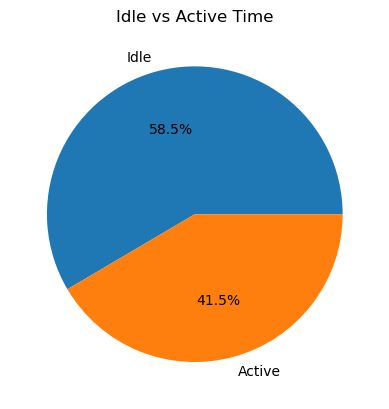

In [22]:
active = 100 - idle_percentage

plt.pie([idle_percentage, active], labels=['Idle','Active'], autopct='%1.1f%%')
plt.title("Idle vs Active Time")
plt.show()

## SAVE FILES AND DATA EXPORT

Save processed datasets for future use and analysis.

Processing Steps:
1. Save daily_count data as CSV file
2. Save daily_energy data as CSV file
3. Create cleaned dataset by removing large time gaps (time_diff > 30)
4. Save cleaned dataset as CSV file
5. Save filtered dataset (without idle data) for analysis

Purpose:
Enable easy access to cleaned and structured data for further analysis, 
sharing, and reproducibility.

In [ ]:

daily_count.to_csv("../output/daily_count.csv", index=False)
daily_energy.to_csv("../output/daily_energy.csv", index=False)

df_cleaned = Battery_DataFrame[Battery_DataFrame['time_diff'] <= 30]
df_cleaned.to_csv("../output/cleaned_dataset.csv", index=False)

Battery_DataFrame_filtered.to_csv("../output/analysis_dataset.csv", index=False)
